# Atividade 3 — Comparação de Classificadores na Base Wine

Comparação entre **Gaussian Naive Bayes** (Teoria da Decisão de Bayes) e um **Classificador Linear** implementado em PyTorch (método linear), avaliando o efeito de normalização, padronização e desbalanceamento artificial.

In [1]:
!pip install torch scikit-learn imbalanced-learn pandas matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importação das bibliotecas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Semente para reprodutibilidade
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.11.0+cpu


## 2. Carregamento e divisão dos dados

Base Wine (178 amostras, 13 atributos, 3 classes) e divisão em 70% treino / 30% teste com estratificação para manter a proporção das classes.

In [3]:
wine = load_wine()
X, y = wine.data, wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")
print(f"Classes no treino: {np.bincount(y_train)}")
print(f"Classes no teste:  {np.bincount(y_test)}")

Treino: 124 amostras
Teste:  54 amostras
Classes no treino: [41 50 33]
Classes no teste:  [18 21 15]


## 3. Definição do Classificador Linear em PyTorch

Classificador linear usando `nn.Linear`. A camada linear aplica a transformação $\mathbf{y} = W\mathbf{x} + \mathbf{b}$ e o treinamento é feito com Cross-Entropy Loss via gradiente descendente.

Este é um **método linear** pois a fronteira de decisão entre as classes é um hiperplano no espaço de atributos.

In [4]:
class LinearClassifier(nn.Module):
    """Classificador linear: uma única camada linear (sem camadas ocultas)."""
    def __init__(self, n_features, n_classes):
        super().__init__()
        self.linear = nn.Linear(n_features, n_classes)

    def forward(self, x):
        return self.linear(x)


def train_linear_classifier(X_train, y_train, X_test, y_test,
                            n_epochs=500, lr=0.01):
    """
    Treina o classificador linear em PyTorch e retorna a acurácia no teste.
    """
    # Converter para tensores
    X_tr = torch.FloatTensor(X_train)
    y_tr = torch.LongTensor(y_train)
    X_te = torch.FloatTensor(X_test)
    y_te = torch.LongTensor(y_test)

    n_features = X_train.shape[1]
    n_classes = len(np.unique(y_train))

    # Inicializar modelo, loss e otimizador
    torch.manual_seed(SEED)
    model = LinearClassifier(n_features, n_classes)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # Treinamento
    model.train()
    for epoch in range(n_epochs):
        optimizer.zero_grad()
        outputs = model(X_tr)
        loss = criterion(outputs, y_tr)
        loss.backward()
        optimizer.step()

    # Avaliação
    model.eval()
    with torch.no_grad():
        preds = model(X_te).argmax(dim=1).numpy()

    return accuracy_score(y_te, preds)

print("Classificador Linear (PyTorch) definido com sucesso.")

Classificador Linear (PyTorch) definido com sucesso.


## 4. Definição do Gaussian Naive Bayes

O **Gaussian Naive Bayes** é um classificador probabilístico baseado na Teoria da Decisão de Bayes. Ele assume:
- Independência condicional entre os atributos dado a classe;
- Distribuição gaussiana para cada atributo dentro de cada classe.

A decisão é tomada pela regra de Bayes: $\hat{y} = \arg\max_c \; P(c) \prod_{k=1}^{d} P(x_k | c)$

In [5]:
def train_naive_bayes(X_train, y_train, X_test, y_test):
    """Treina Gaussian Naive Bayes e retorna a acuracia no teste."""
    model = GaussianNB()
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return accuracy_score(y_test, preds)

print("Gaussian Naive Bayes definido com sucesso.")

Gaussian Naive Bayes definido com sucesso.


In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

results = []
all_preds = {}  # guardar predições para visualização

scenarios = {
    'Sem tratamento': None,
    'Z-Score': StandardScaler(),
    'Min-Max': MinMaxScaler(),
}

for name, scaler in scenarios.items():
    if scaler is not None:
        X_tr = scaler.fit_transform(X_train)
        X_te = scaler.transform(X_test)
    else:
        X_tr = X_train.copy()
        X_te = X_test.copy()

    # Naive Bayes
    nb = GaussianNB()
    nb.fit(X_tr, y_train)
    preds_nb = nb.predict(X_te)
    acc_nb = accuracy_score(y_test, preds_nb)

    # Classificador Linear (PyTorch)
    torch.manual_seed(SEED)
    X_tr_t = torch.FloatTensor(X_tr)
    y_tr_t = torch.LongTensor(y_train)
    X_te_t = torch.FloatTensor(X_te)

    model = LinearClassifier(X_tr.shape[1], 3)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.01)

    losses = []
    model.train()
    for epoch in range(500):
        optimizer.zero_grad()
        out = model(X_tr_t)
        loss = criterion(out, y_tr_t)
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            losses.append(loss.item())

    model.eval()
    with torch.no_grad():
        preds_lc = model(X_te_t).argmax(dim=1).numpy()
    acc_lc = accuracy_score(y_test, preds_lc)

    all_preds[name] = {
        'preds_nb': preds_nb, 'preds_lc': preds_lc,
        'acc_nb': acc_nb, 'acc_lc': acc_lc,
        'losses': losses, 'X_te': X_te,
    }

    results.append({
        'Pré-processamento': name,
        'Naive Bayes (%)': round(acc_nb * 100, 2),
        'Linear PyTorch (%)': round(acc_lc * 100, 2),
    })

    print(f"{name:16s} | NB: {acc_nb*100:.2f}% | Linear: {acc_lc*100:.2f}%")

df_results = pd.DataFrame(results)
df_results

Sem tratamento   | NB: 100.00% | Linear: 51.85%
Z-Score          | NB: 100.00% | Linear: 96.30%
Min-Max          | NB: 100.00% | Linear: 92.59%


,Pré-processamento,Naive Bayes (%),Linear PyTorch (%)
0,Sem tratamento,100.0,51.85
1,Z-Score,100.0,96.30
2,Min-Max,100.0,92.59


### Matrizes de Confusão do Classificador Linear

As matrizes de confusão mostram, para cada pré-processamento, quantas amostras de cada classe foram classificadas corretamente (diagonal) e onde ocorreram os erros. É possível ver que sem tratamento o modelo erra muito, concentrando predições em uma única classe.

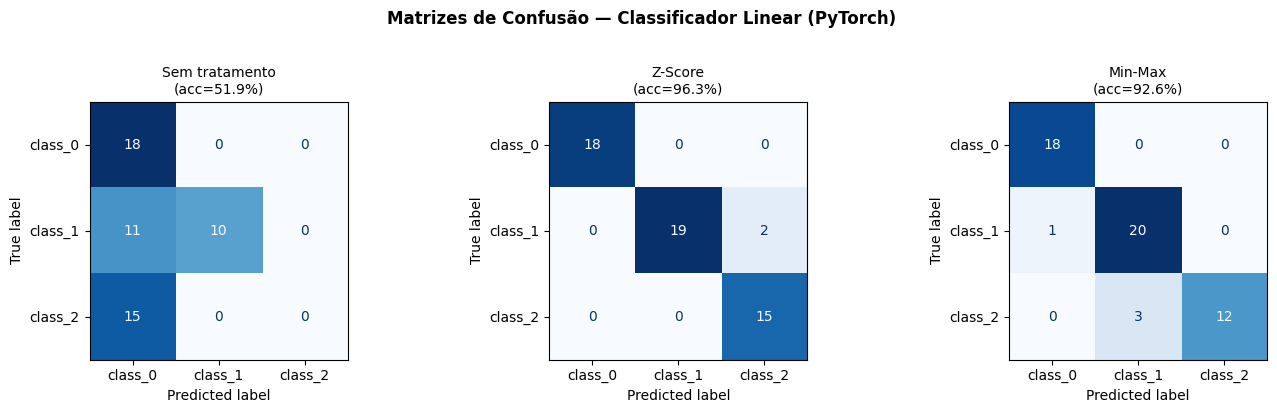

In [7]:
# Gráfico 2: Matrizes de confusão do Classificador Linear por pré-processamento
scenario_names = list(all_preds.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, scenario_names):
    cm = confusion_matrix(y_test, all_preds[name]['preds_lc'])
    disp = ConfusionMatrixDisplay(cm, display_labels=wine.target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    acc = all_preds[name]['acc_lc'] * 100
    ax.set_title(f'{name}\n(acc={acc:.1f}%)', fontsize=10)

plt.suptitle('Matrizes de Confusão — Classificador Linear (PyTorch)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusao_linear.png', bbox_inches='tight')
plt.show()

### Dispersão PCA 2D — Predições vs Rótulos Reais

Para visualizar as predições no espaço, reduzimos os 13 atributos para 2 dimensões via PCA. Cada ponto é colorido pelo rótulo **predito** pelo classificador linear (marcadores errados aparecem com borda vermelha), permitindo ver onde os erros ocorrem.

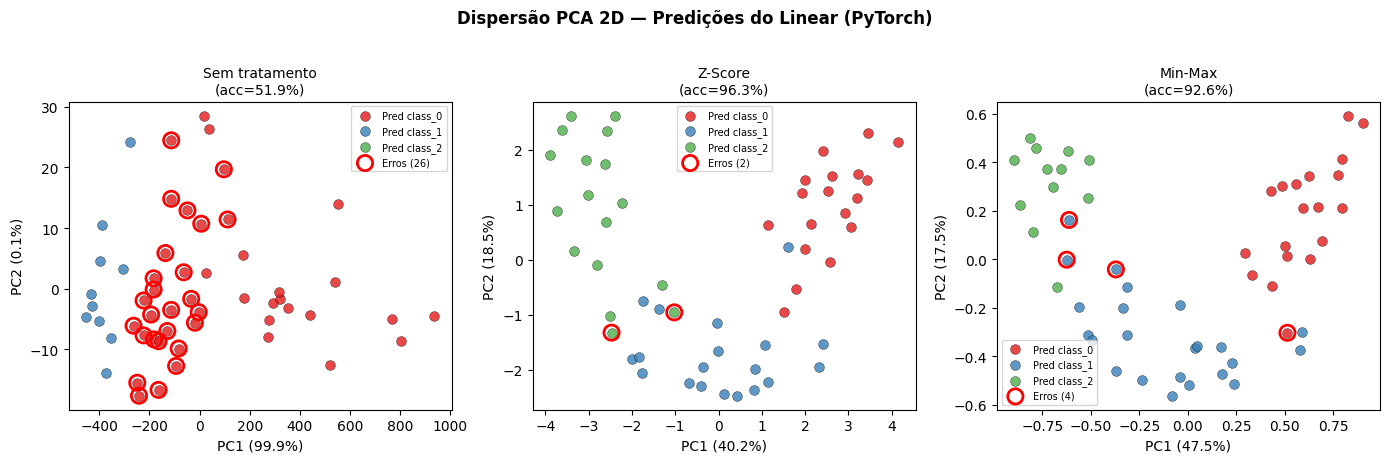

In [8]:
# Gráfico 3: Dispersão PCA 2D — Predições do Classificador Linear
colors_cls = ['#e41a1c', '#377eb8', '#4daf4a']
scenario_names = list(all_preds.keys())

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, name in zip(axes, scenario_names):
    X_te = all_preds[name]['X_te']
    preds = all_preds[name]['preds_lc']

    # PCA para 2D
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_te)

    # Plotar cada ponto colorido pela predição
    for c in range(3):
        mask = preds == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors_cls[c], label=f'Pred {wine.target_names[c]}',
                   alpha=0.8, edgecolors='k', linewidths=0.3, s=50)

    # Marcar erros com X vermelho
    erros = preds != y_test
    if erros.any():
        ax.scatter(X_2d[erros, 0], X_2d[erros, 1],
                   c='none', edgecolors='red', linewidths=2, s=120,
                   marker='o', label=f'Erros ({erros.sum()})')

    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
    acc = all_preds[name]['acc_lc'] * 100
    ax.set_title(f'{name}\n(acc={acc:.1f}%)', fontsize=10)
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Dispersão PCA 2D — Predições do Linear (PyTorch)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_dispersao_linear.png', bbox_inches='tight')
plt.show()

### Matrizes de Confusão o Naive Bayes

Comparação direta com o Classificador Linear.

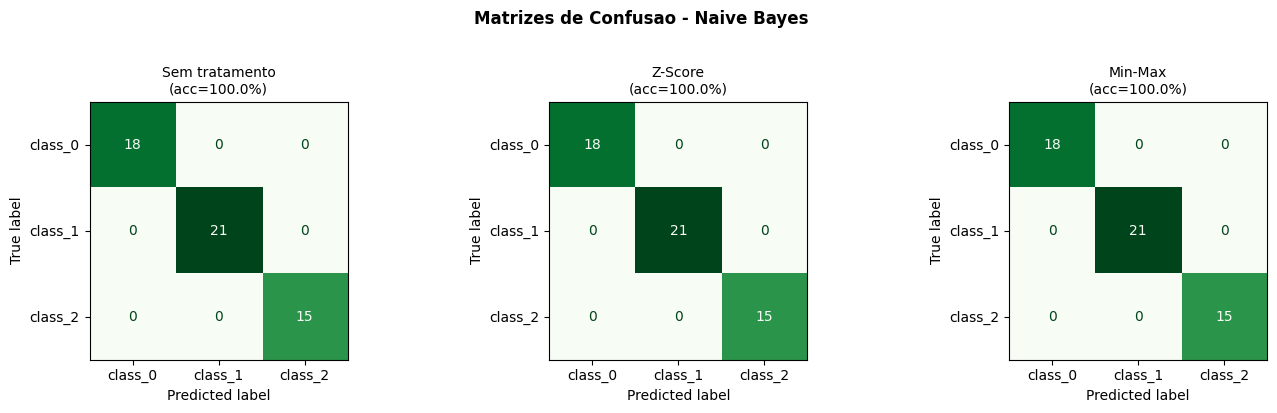

In [9]:
# Matrizes de confusao do Naive Bayes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, scenario_names):
    cm = confusion_matrix(y_test, all_preds[name]["preds_nb"])
    disp = ConfusionMatrixDisplay(cm, display_labels=wine.target_names)
    disp.plot(ax=ax, cmap="Greens", colorbar=False)
    acc = all_preds[name]["acc_nb"] * 100
    titulo = name + chr(10) + f"(acc={acc:.1f}%)"
    ax.set_title(titulo, fontsize=10)

plt.suptitle("Matrizes de Confusao - Naive Bayes", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusao_nb.png", bbox_inches="tight")
plt.show()

### Dispersaoo PCA 2D a Naive Bayes

Predicoeses do Naive Bayes projetadas em 2D via PCA. Erros (se houver) saoo destacados com circulorculo vermelho.

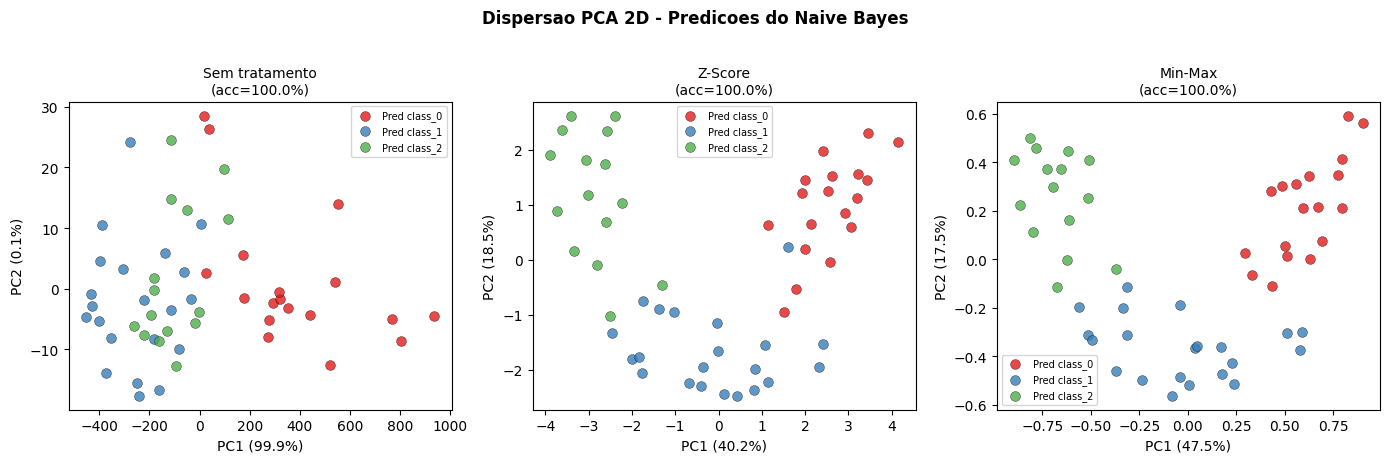

In [10]:
# Dispersao PCA 2D - Predicoes do Naive Bayes
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ax, name in zip(axes, scenario_names):
    X_te = all_preds[name]["X_te"]
    preds = all_preds[name]["preds_nb"]

    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_te)

    for c in range(3):
        mask = preds == c
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=colors_cls[c], label=f"Pred {wine.target_names[c]}",
                   alpha=0.8, edgecolors="k", linewidths=0.3, s=50)

    erros = preds != y_test
    if erros.any():
        ax.scatter(X_2d[erros, 0], X_2d[erros, 1],
                   c="none", edgecolors="red", linewidths=2, s=120,
                   marker="o", label=f"Erros ({erros.sum()})")

    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    acc = all_preds[name]["acc_nb"] * 100
    titulo = name + chr(10) + f"(acc={acc:.1f}%)"
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=7, loc="best")

plt.suptitle("Dispersao PCA 2D - Predicoes do Naive Bayes", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("pca_dispersao_nb.png", bbox_inches="tight")
plt.show()

### Visualização dos resultados

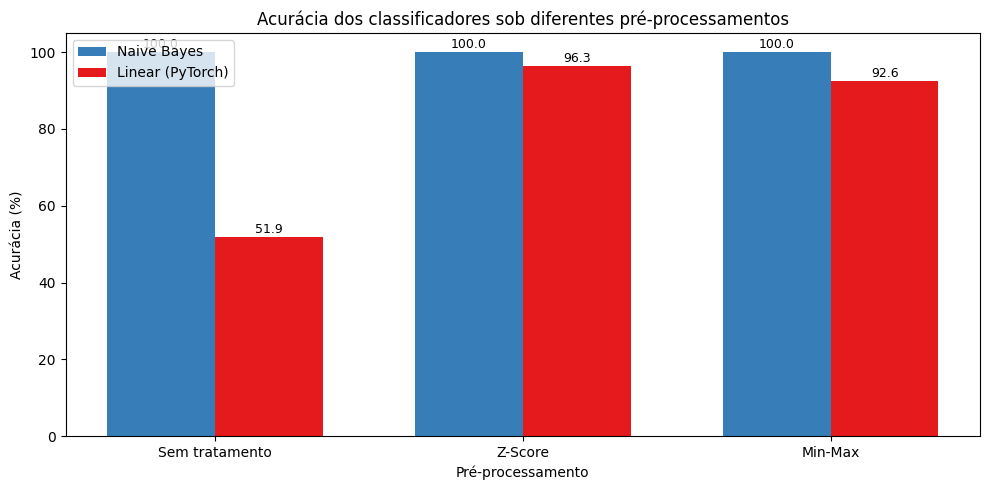

In [11]:
x_pos = np.arange(len(df_results))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, df_results['Naive Bayes (%)'],
               width, label='Naive Bayes', color='#377eb8')
bars2 = ax.bar(x_pos + width/2, df_results['Linear PyTorch (%)'],
               width, label='Linear (PyTorch)', color='#e41a1c')

ax.set_xlabel('Pré-processamento')
ax.set_ylabel('Acurácia (%)')
ax.set_title('Acurácia dos classificadores sob diferentes pré-processamentos')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_results['Pré-processamento'])
ax.set_ylim(0, 105)
ax.legend()

# Valores sobre as barras
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparacao_preprocessamento.png', bbox_inches='tight')
plt.show()

### Discussão

- O **Naive Bayes** calcula verossimilhanças atributo a atributo de forma independente, então a mudança de escala tem efeito limitado na sua acurácia.
- O **Classificador Linear (PyTorch)**, treinado por gradiente descendente, é sensível à escala dos atributos. Sem pré-processamento, as superfícies de custo são elipsóides alongados, dificultando a convergência. Com Z-Score ou Min-Max, o gradiente converge mais rapidamente e a acurácia melhora.
- O melhor pré-processamento identificado será utilizado na próxima etapa.

## 6. Identificação do melhor pré-processamento

In [12]:
# Selecionar o pré-processamento com maior acurácia média entre os dois métodos
df_results['Média (%)'] = (
    df_results['Naive Bayes (%)'] + df_results['Linear PyTorch (%)']
) / 2

best_idx = df_results['Média (%)'].idxmax()
best_preproc = df_results.loc[best_idx, 'Pré-processamento']

print(f"Melhor pré-processamento: {best_preproc}")
print(f"Acurácia média: {df_results.loc[best_idx, 'Média (%)']:.2f}%")

# Definir o scaler a ser usado daqui em diante
if best_preproc == 'Z-Score':
    best_scaler = StandardScaler()
elif best_preproc == 'Min-Max':
    best_scaler = MinMaxScaler()
else:
    best_scaler = None

Melhor pré-processamento: Z-Score
Acurácia média: 98.15%


## 7. Desbalanceamento artificial do conjunto de treino

Distribuição forçada do conjunto de **treino** para 60%-25%-15% entre as 3 classes, simulando um cenário de desbalanceamento. O conjunto de **teste** permanece inalterado para uma avaliação justa.

In [13]:
def create_imbalanced(X, y, class_proportions={0: 0.60, 1: 0.25, 2: 0.15}, seed=42):
    """
    Cria desbalanceamento artificial com proporcoes fixas por classe.
    classe 0 = 60%, classe 1 = 25%, classe 2 = 15%
    """
    rng = np.random.RandomState(seed)
    total = len(y)

    X_imb, y_imb = [], []
    for cls, prop in class_proportions.items():
        idx = np.where(y == cls)[0]
        n_target = int(total * prop)
        chosen = rng.choice(idx, size=n_target, replace=True)
        X_imb.append(X[chosen])
        y_imb.append(y[chosen])

    return np.vstack(X_imb), np.concatenate(y_imb)


X_train_imb, y_train_imb = create_imbalanced(X_train, y_train)

print("Distribuicao original do treino:")
for c in np.unique(y_train):
    n = np.sum(y_train == c)
    print(f"  Classe {c}: {n} amostras ({n/len(y_train)*100:.1f}%)")

print()
print("Distribuicao desbalanceada do treino:")
for c in np.unique(y_train_imb):
    n = np.sum(y_train_imb == c)
    print(f"  Classe {c}: {n} amostras ({n/len(y_train_imb)*100:.1f}%)")


Distribuicao original do treino:
  Classe 0: 41 amostras (33.1%)
  Classe 1: 50 amostras (40.3%)
  Classe 2: 33 amostras (26.6%)

Distribuicao desbalanceada do treino:
  Classe 0: 74 amostras (60.2%)
  Classe 1: 31 amostras (25.2%)
  Classe 2: 18 amostras (14.6%)


## 8. Aplicação de Undersampling e Oversampling

- **Undersampling** (`RandomUnderSampler`): reduz a classe majoritária ao tamanho da minoritária.
- **Oversampling** (`SMOTE`): gera amostras sintéticas para as classes minoritárias por interpolação entre vizinhos mais próximos.

Ambas as técnicas são aplicadas **apenas ao conjunto de treino**.

In [14]:
# Undersampling
rus = RandomUnderSampler(random_state=SEED)
X_train_under, y_train_under = rus.fit_resample(X_train_imb, y_train_imb)

# Oversampling (SMOTE)
# k_neighbors precisa ser menor que o número de amostras da menor classe
min_class_count = min(np.bincount(y_train_imb))
k_neighbors = min(5, min_class_count - 1)
smote = SMOTE(random_state=SEED, k_neighbors=k_neighbors)
X_train_over, y_train_over = smote.fit_resample(X_train_imb, y_train_imb)

print("Após Undersampling:")
for c in np.unique(y_train_under):
    n = np.sum(y_train_under == c)
    print(f"  Classe {c}: {n} amostras")

print(f"\nApós Oversampling (SMOTE):")
for c in np.unique(y_train_over):
    n = np.sum(y_train_over == c)
    print(f"  Classe {c}: {n} amostras")

Após Undersampling:
  Classe 0: 18 amostras
  Classe 1: 18 amostras
  Classe 2: 18 amostras

Após Oversampling (SMOTE):
  Classe 0: 74 amostras
  Classe 1: 74 amostras
  Classe 2: 74 amostras


## 9. Avaliação: Desbalanceado vs Undersampling vs Oversampling

Aplicamos o melhor pré-processamento identificado na etapa anterior e comparamos os dois classificadores nos três cenários.

In [15]:
train_sets = {
    'Desbalanceado': (X_train_imb, y_train_imb),
    '+ Undersampling': (X_train_under, y_train_under),
    '+ Oversampling (SMOTE)': (X_train_over, y_train_over),
}

results_imb = []

for name, (X_tr_raw, y_tr) in train_sets.items():
    # Aplicar pré-processamento
    if best_scaler is not None:
        scaler = best_scaler.__class__()  # nova instância do mesmo tipo
        X_tr = scaler.fit_transform(X_tr_raw)
        X_te = scaler.transform(X_test)
    else:
        X_tr = X_tr_raw.copy()
        X_te = X_test.copy()

    # Naive Bayes
    acc_nb = train_naive_bayes(X_tr, y_tr, X_te, y_test)

    # Classificador Linear (PyTorch)
    acc_lc = train_linear_classifier(X_tr, y_tr, X_te, y_test)

    results_imb.append({
        'Cenário': name,
        'Naive Bayes (%)': round(acc_nb * 100, 2),
        'Linear PyTorch (%)': round(acc_lc * 100, 2),
    })

    print(f"{name:25s} | NB: {acc_nb*100:.2f}% | Linear: {acc_lc*100:.2f}%")

df_imb = pd.DataFrame(results_imb)
df_imb

Desbalanceado             | NB: 98.15% | Linear: 92.59%
+ Undersampling           | NB: 92.59% | Linear: 94.44%
+ Oversampling (SMOTE)    | NB: 98.15% | Linear: 92.59%


,Cenário,Naive Bayes (%),Linear PyTorch (%)
0,Desbalanceado,98.15,92.59
1,+ Undersampling,92.59,94.44
2,+ Oversampling (SMOTE),98.15,92.59


### Visualização dos resultados com desbalanceamento

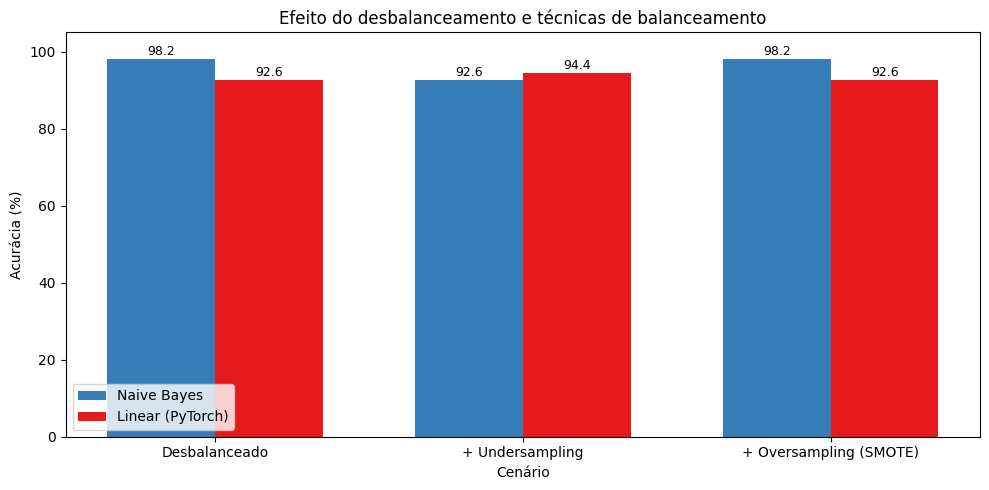

In [16]:
x_pos = np.arange(len(df_imb))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x_pos - width/2, df_imb['Naive Bayes (%)'],
               width, label='Naive Bayes', color='#377eb8')
bars2 = ax.bar(x_pos + width/2, df_imb['Linear PyTorch (%)'],
               width, label='Linear (PyTorch)', color='#e41a1c')

ax.set_xlabel('Cenário')
ax.set_ylabel('Acurácia (%)')
ax.set_title('Efeito do desbalanceamento e técnicas de balanceamento')
ax.set_xticks(x_pos)
ax.set_xticklabels(df_imb['Cenário'])
ax.set_ylim(0, 105)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('comparacao_desbalanceamento.png', bbox_inches='tight')
plt.show()

## 10. Tabela resumo final

In [17]:
print("=" * 65)
print(" PARTE 1: Efeito do pré-processamento")
print("=" * 65)
display(df_results[['Pré-processamento', 'Naive Bayes (%)', 'Linear PyTorch (%)']])

print(f"\nMelhor pré-processamento: {best_preproc}")

print("\n" + "=" * 65)
print(" PARTE 2: Efeito do desbalanceamento")
print("=" * 65)
display(df_imb)

 PARTE 1: Efeito do pré-processamento


,Pré-processamento,Naive Bayes (%),Linear PyTorch (%)
0,Sem tratamento,100.0,51.85
1,Z-Score,100.0,96.30
2,Min-Max,100.0,92.59



Melhor pré-processamento: Z-Score

 PARTE 2: Efeito do desbalanceamento


,Cenário,Naive Bayes (%),Linear PyTorch (%)
0,Desbalanceado,98.15,92.59
1,+ Undersampling,92.59,94.44
2,+ Oversampling (SMOTE),98.15,92.59


## 11. Conclusões

### Pré-processamento
- O **Naive Bayes** é pouco afetado pela mudança de escala, pois calcula verossimilhanças gaussianas por atributo de forma independente — a escala é absorvida pelos parâmetros ($\mu$, $\sigma$) estimados.
- O **Classificador Linear (PyTorch)**, treinado por gradiente descendente, se beneficia significativamente da padronização/normalização, pois escalas homogêneas tornam a superfície de custo mais isotrópica e facilitam a convergência.

### Desbalanceamento
- O desbalanceamento artificial (60-25-15%) tende a enviesar ambos os classificadores para a classe majoritária.
- O **Undersampling** reduz o viés, mas ao custo de descartar dados da classe majoritária, podendo aumentar a variância.
- O **Oversampling (SMOTE)** gera amostras sintéticas para as classes minoritárias, geralmente oferecendo um melhor equilíbrio entre viés e variância.
- A estratégia mais adequada depende do classificador e da estrutura dos dados — os resultados numéricos acima permitem identificar qual abordagem funcionou melhor para cada método.